In [73]:
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
X, y =load_digits().data, load_digits().target

In [14]:
X.shape

(1797, 64)

In [15]:
y.shape

(1797,)

In [26]:
X[1].reshape(-1,8) # 8 by 8  숫자가 높은 애들을 흐린눈 해서 보면 1로 보임

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

In [27]:
y[1]  # 1에 이미지 1이 들어있음

np.int64(1)

In [21]:
X[2].reshape(-1,8) # 8 by 8  숫자가 높은 애들을 흐린눈 해서 보면 2로 보임

array([[ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.],
       [ 0.,  0.,  3., 16., 15., 14.,  0.,  0.],
       [ 0.,  0.,  8., 13.,  8., 16.,  0.,  0.],
       [ 0.,  0.,  1.,  6., 15., 11.,  0.,  0.],
       [ 0.,  1.,  8., 13., 15.,  1.,  0.,  0.],
       [ 0.,  9., 16., 16.,  5.,  0.,  0.,  0.],
       [ 0.,  3., 13., 16., 16., 11.,  5.,  0.],
       [ 0.,  0.,  0.,  3., 11., 16.,  9.,  0.]])

In [22]:
y[2]  # 2에 이미지 2이 들어있음

np.int64(2)

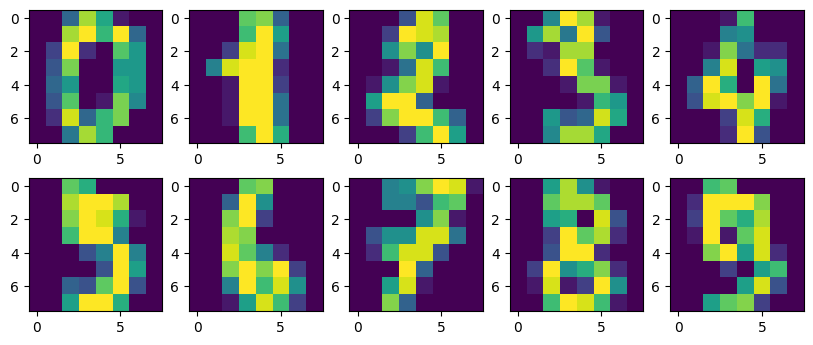

In [34]:
fig, axes = plt.subplots(2,5, figsize=(10,4))
for ax, img, label in zip(axes.ravel(), load_digits().images[:10], y[:10]):   # zip하면 ax img labe이 튜플로 묶임
    ax.imshow(img)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
# 개별 모델 정의
model1 = LogisticRegression(random_state=42, max_iter=200)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC(probability=True, random_state=42)  # Soft Voting용

In [38]:
# Voting Classifier 생성
voting_clf = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svc', model3)],  # 이렇게 이름을 지정해주면 뒤에가서 이름으로 하이퍼파라미터 조정가능
    voting='soft')  # 'hard' 또는 'soft'인데 소프트가 좀 더 나음

In [39]:
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [40]:
voting_clf.score(X_test, y_test)

0.9777777777777777

In [42]:
voting_clf.predict_proba(X_test) [:1] # 1개만 꺼냄

array([[2.17889351e-03, 7.37872488e-04, 4.75774556e-04, 5.43724225e-04,
        1.17588169e-03, 1.12729832e-03, 9.89469486e-01, 4.61907837e-04,
        2.44948461e-03, 1.37967656e-03]])

In [43]:
y_test[:1] # 위에 6의 예측 확률 보면 98.9%가 가장 높음

array([6])

In [44]:
lr = LogisticRegression()

In [51]:
lr.fit(X_train, y_train)

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9648148148148148

In [46]:
lr.score(X_test, y_test)

0.9648148148148148

In [47]:
dt = DecisionTreeClassifier()

In [48]:
dt.fit(X_train, y_train)
dt.score(X_test, y_test)

0.8537037037037037

In [49]:
svc = SVC()

In [50]:
svc.fit(X_train, y_train)
svc.score(X_test, y_test)

0.987037037037037

In [53]:
bc = BaggingClassifier(estimator= SVC(), n_estimators=100)

In [54]:
bc.fit(X_train, y_train)
bc.score(X_test, y_test)

0.9907407407407407

In [56]:
rf = RandomForestClassifier()

In [57]:
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.975925925925926

In [ ]:
# 실습: 개별 모델 vs Voting 성능 비교 ppt 9page

In [59]:
# with weights

In [62]:
voting_clf_weight = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svc', model3)],    
    voting='soft',
    weights=[1,2,3])   

In [64]:
# 1) 먼저 학습
voting_clf_weight.fit(X_train, y_train)

# 2) 그 다음 평가
voting_score = voting_clf_weight.score(X_test, y_test)
print("VotingClassifier 정확도:", voting_score)

VotingClassifier 정확도: 0.9777777777777777


In [65]:
from sklearn.ensemble import StackingClassifier

In [66]:
# Base Models (Level 0)
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))]

# Meta Model (Level 1)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

In [67]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # 5-Fold for Out-of-Fold predictions
)

# 학습
stacking_clf.fit(X_train, y_train)

# 평가
stacking_clf.score(X_test, y_test)

0.9851851851851852

# Grid Search

In [72]:
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))]

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42))

In [74]:
# 파라미터 그리드
param_grid = {
    'dt__max_depth': [3, 5, 7],  # dt__ (dt 언더바 2개) 하면  dt의 ___ 임 2:38분
    'rf__n_estimators': [50, 100], # 모델 갯수
    'rf__max_depth': [5, 10],
    'svc__C': [0.1, 1, 10],
    'cv': [3, 5],
    'passthrough': [False, True],
    'final_estimator__C': [0.1, 1, 10]}

# Grid Search
grid_search = GridSearchCV(
    stacking_clf,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1)

In [75]:
grid_search.fit(X_train, y_train)
print(f"최적 CV 점수: {grid_search.best_score_:.4f}")

최적 CV 점수: 0.9865
